#  Emotion Detection — CNN + SpecAugment
Amélioration du CNN de base avec SpecAugment (masquage fréquences + temps)

---
##  Cellule 1 — Imports & Device
> Identique au notebook CNN de base

In [45]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device : {device}')

EMOTIONS  = ['angry','calm','disgust','fearful','happy','neutral','sad','surprised']
NUM_CLASS = len(EMOTIONS)
OUT       = '/kaggle/working'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f' Seed fixée à {SEED}')

 Device : cuda
 Seed fixée à 42


---
##  Cellule 2 — Chargement & Normalisation
> Identique au notebook CNN de base

In [46]:
X_train = np.load(os.path.join(OUT, 'X_train.npy'))
y_train = np.load(os.path.join(OUT, 'y_train.npy'))
X_val   = np.load(os.path.join(OUT, 'X_val.npy'))
y_val   = np.load(os.path.join(OUT, 'y_val.npy'))
X_test  = np.load(os.path.join(OUT, 'X_test.npy'))
y_test  = np.load(os.path.join(OUT, 'y_test.npy'))

mean = X_train.mean()
std  = X_train.std()
X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)

X_train = X_train[:, np.newaxis, :, :]
X_val   = X_val[:,   np.newaxis, :, :]
X_test  = X_test[:,  np.newaxis, :, :]

print(f' X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}')

 X_train : (3840, 1, 128, 126) | X_val : (240, 1, 128, 126) | X_test : (240, 1, 128, 126)


---
##  Cellule 3 — SpecAugment  ← NOUVEAU

**Principe :** pendant l'entraînement, on masque aléatoirement :
- des **bandes de fréquences** (lignes horizontales dans le spectrogramme)
- des **intervalles de temps** (colonnes verticales)

Cela force le modèle à ne pas se fier à une seule région du spectrogramme.

 SpecAugment configuré :
   FrequencyMasking × 2 (max 20 bandes)
   TimeMasking      × 2 (max 25 frames)


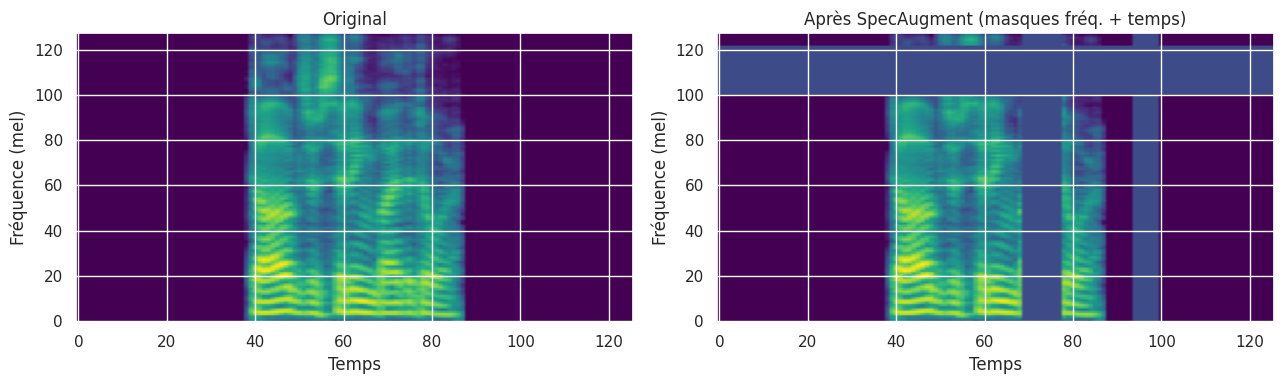

 Visualisation sauvegardée


In [47]:
# SpecAugment : appliqué UNIQUEMENT pendant le train, jamais sur val/test
spec_augment = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=20),  # masque jusqu'à 20 bandes mel
    T.FrequencyMasking(freq_mask_param=20),  # 2 masques fréquence
    T.TimeMasking(time_mask_param=25),        # masque jusqu'à 25 frames
    T.TimeMasking(time_mask_param=25),        # 2 masques temps
).to(device)

print(' SpecAugment configuré :')
print('   FrequencyMasking × 2 (max 20 bandes)')
print('   TimeMasking      × 2 (max 25 frames)')

# Visualisation de l'effet SpecAugment sur un exemple
sample = torch.tensor(X_train[0:1], dtype=torch.float32).to(device)
augmented = spec_augment(sample.clone())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(sample[0, 0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original')
axes[0].set_xlabel('Temps')
axes[0].set_ylabel('Fréquence (mel)')

axes[1].imshow(augmented[0, 0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Après SpecAugment (masques fréq. + temps)')
axes[1].set_xlabel('Temps')
axes[1].set_ylabel('Fréquence (mel)')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'specaugment_exemple.png'), bbox_inches='tight')
plt.show()
print(' Visualisation sauvegardée')

---
##  Cellule 4 — Dataset & DataLoaders

In [48]:
class SERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_dataset = SERDataset(X_train, y_train)
val_dataset   = SERDataset(X_val,   y_val)
test_dataset  = SERDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f' Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}')

 Train : 3840 | Val : 240 | Test : 240


---
##  Cellule 5 — Architecture CNN
> Identique au notebook CNN de base

In [49]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        def conv_block(in_ch, out_ch, dropout=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout),
            )

        self.features = nn.Sequential(
            conv_block(1,   32,  dropout=0.20),
            conv_block(32,  64,  dropout=0.25),
            conv_block(64,  128, dropout=0.25),
            conv_block(128, 256, dropout=0.30),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = EmotionCNN(num_classes=NUM_CLASS).to(device)
total = sum(p.numel() for p in model.parameters())
print(f' Modèle OK — {total:,} paramètres')

 Modèle OK — 1,272,360 paramètres


---
##  Cellule 6 — Configuration entraînement

In [50]:
EPOCHS   = 60   # plus d'epochs car SpecAugment ralentit la convergence
LR       = 1e-3
PATIENCE = 12   # patience augmentée aussi

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

print(f' Epochs : {EPOCHS} | Patience : {PATIENCE}')
print(f'   SpecAugment actif sur le TRAIN uniquement')

 Epochs : 60 | Patience : 12
   SpecAugment actif sur le TRAIN uniquement


---
##  Cellule 7 — Boucle d'entraînement avec SpecAugment  ← MODIFIÉE

In [51]:
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = os.path.join(OUT, 'best_model_specaug.pt')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # SpecAugment appliqué ici — seulement pendant le TRAIN
        X_batch = spec_augment(X_batch)

        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (out.argmax(1) == y_batch).sum().item()

    # ── VALIDATION — sans SpecAugment ──────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            #  PAS de SpecAugment ici
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (out.argmax(1) == y_batch).sum().item()

    tl = train_loss    / len(train_dataset)
    ta = train_correct / len(train_dataset)
    vl = val_loss      / len(val_dataset)
    va = val_correct   / len(val_dataset)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    scheduler.step()

    if vl < best_val_loss:
        best_val_loss    = vl
        patience_counter = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_loss'   : vl,
            'val_acc'    : va,
        }, best_model_path)
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train {tl:.4f} / {ta:.2%} | '
              f'Val {vl:.4f} / {va:.2%} | '
              f'Patience {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping à l\'epoch {epoch}')
        break

print(f'\n Terminé — meilleur val_loss : {best_val_loss:.4f}')

Epoch 01/60 | Train 2.0704 / 15.36% | Val 2.0005 / 29.58% | Patience 0/12
Epoch 05/60 | Train 1.9648 / 24.11% | Val 1.9245 / 25.00% | Patience 0/12
Epoch 10/60 | Train 1.8469 / 30.89% | Val 1.7958 / 34.58% | Patience 0/12
Epoch 15/60 | Train 1.8142 / 32.68% | Val 1.7017 / 36.67% | Patience 0/12
Epoch 20/60 | Train 1.7633 / 35.62% | Val 2.0219 / 27.08% | Patience 3/12
Epoch 25/60 | Train 1.6812 / 41.25% | Val 1.6614 / 37.92% | Patience 2/12
Epoch 30/60 | Train 1.6484 / 42.24% | Val 1.6282 / 43.33% | Patience 4/12
Epoch 35/60 | Train 1.6282 / 43.59% | Val 1.5659 / 45.00% | Patience 0/12
Epoch 40/60 | Train 1.5590 / 46.74% | Val 1.5518 / 45.83% | Patience 0/12
Epoch 45/60 | Train 1.5391 / 48.54% | Val 1.5314 / 46.25% | Patience 0/12
Epoch 50/60 | Train 1.5206 / 49.06% | Val 1.5228 / 47.92% | Patience 2/12
Epoch 55/60 | Train 1.4971 / 50.21% | Val 1.5323 / 47.08% | Patience 7/12
Epoch 60/60 | Train 1.4833 / 51.20% | Val 1.5278 / 46.67% | Patience 12/12

  Early stopping à l'epoch 60

 Term

---
##  Cellule 8 — Courbes d'apprentissage

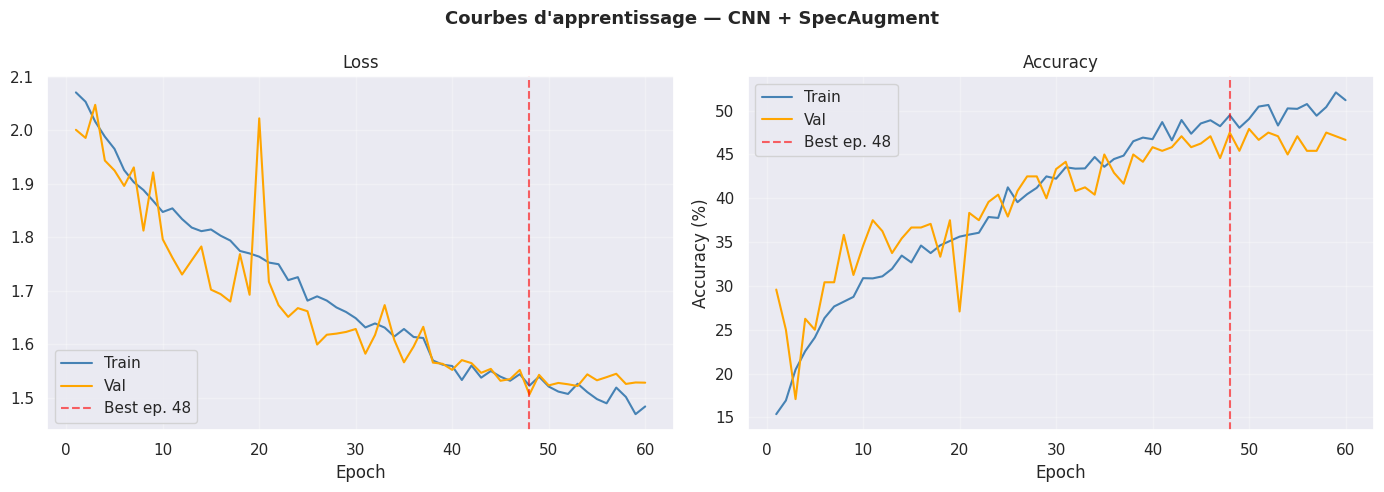

Best epoch : 48 | Best val acc : 47.92%


In [52]:
epochs_range = range(1, len(history['train_loss']) + 1)
best_ep      = np.argmin(history['val_loss']) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — CNN + SpecAugment', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='orange')
axes[0].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val',   color='orange')
axes[1].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best ep. {best_ep}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'courbes_specaug.png'), bbox_inches='tight')
plt.show()
print(f'Best epoch : {best_ep} | Best val acc : {max(history["val_acc"]):.2%}')

---
##  Cellule 9 — Évaluation Test + Comparaison

In [55]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f' Meilleur modèle chargé (epoch {checkpoint["epoch"]} | val_acc {checkpoint["val_acc"]:.2%})')

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
test_acc  = (all_preds == all_true).mean()

print(f'\n=== Résultats Test Set ===')
print(f'Accuracy : {test_acc:.2%}')
print()
print(classification_report(all_true, all_preds, target_names=EMOTIONS, digits=3, zero_division=0))

# ── Comparaison avec CNN de base ───────────────────────
baseline_acc = 0.5083   # ← remplace par ton résultat précis
gain         = test_acc - baseline_acc
print('=' * 40)
print(f'CNN de base      : {baseline_acc:.2%}')
print(f'CNN + SpecAugment: {test_acc:.2%}')
print(f'Gain             : {gain:+.2%}')
print('=' * 40)

 Meilleur modèle chargé (epoch 48 | val_acc 47.50%)

=== Résultats Test Set ===
Accuracy : 45.42%

              precision    recall  f1-score   support

       angry      0.400     0.375     0.387        32
        calm      0.373     0.875     0.523        32
     disgust      0.446     0.906     0.598        32
     fearful      0.667     0.250     0.364        32
       happy      0.500     0.031     0.059        32
     neutral      0.000     0.000     0.000        16
         sad      0.083     0.031     0.045        32
   surprised      0.682     0.938     0.789        32

    accuracy                          0.454       240
   macro avg      0.394     0.426     0.346       240
weighted avg      0.420     0.454     0.369       240

CNN de base      : 50.83%
CNN + SpecAugment: 45.42%
Gain             : -5.41%


---
##  Cellule 10 — Matrice de confusion + UAR

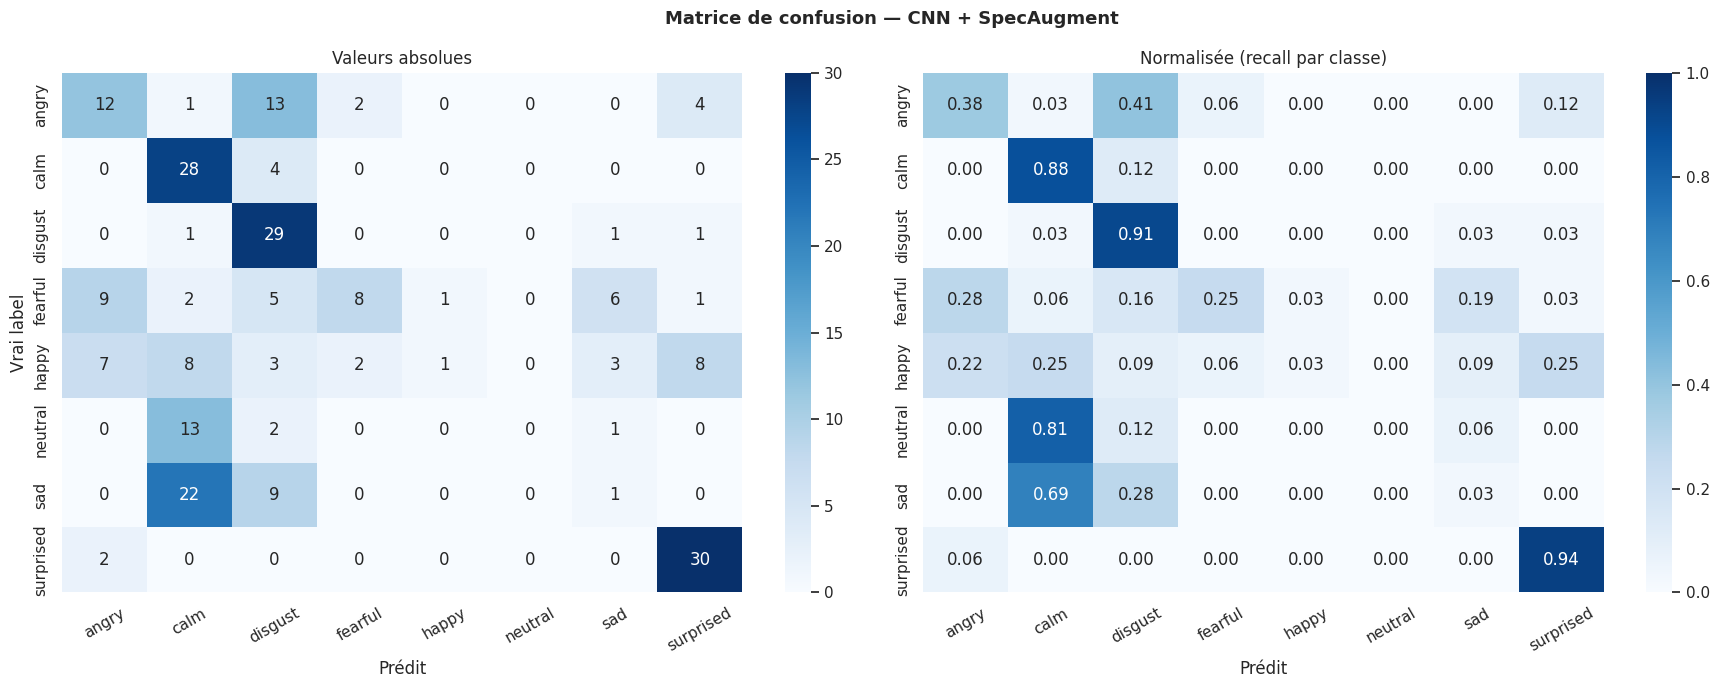


 UAR : 42.58% | Accuracy : 45.42%

  angry        37.50%  ███████
  calm         87.50%  █████████████████
  disgust      90.62%  ██████████████████
  fearful      25.00%  █████
  happy        3.12%  
  neutral      0.00%  
  sad          3.12%  
  surprised    93.75%  ██████████████████


In [56]:
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrice de confusion — CNN + SpecAugment', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Valeurs absolues')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Prédit')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalisée (recall par classe)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Prédit')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'confusion_specaug.png'), bbox_inches='tight')
plt.show()

recalls = cm.diagonal() / cm.sum(axis=1)
uar     = recalls.mean()
print(f'\n UAR : {uar:.2%} | Accuracy : {test_acc:.2%}')
print()
for emo, rec in zip(EMOTIONS, recalls):
    bar = '█' * int(rec * 20)
    print(f'  {emo:<12} {rec:.2%}  {bar}')